In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import scipy.stats
import networkx as nx

import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import p_lithostatic, T_geothermal, MagmaChamber, GlobalSystem, GlobalSystemThreshold
import percolation_network

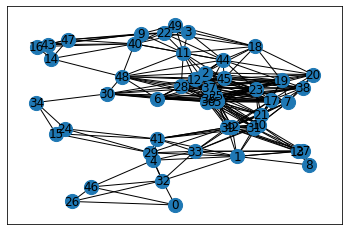

In [2]:
np.random.seed(0)
N = 50
x_scale = 20e3
z_scale = 40e3
R = 500

node_list = percolation_network.make_2D_random_network(
  N, x_scale=x_scale, z_scale=z_scale, R_min=R, R_max=R,)
props = percolation_network.prop_factory(t_b=1e11, t_d=5e10, K_crust=10e9,
  G_crust=10e9, K_f=10e9, rho0=2500, mu0=1e6, r_hydr=5)
RG = percolation_network.RandomGraph(node_list, 0.2 * z_scale)

edge_conductivity = RG.edge_conductivity_list()
RG.draw_network()


Conductance of each edge (dot); full-graph network effective conductance (dashed)


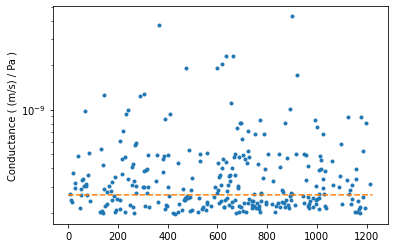

In [3]:
# Compute scaling that when multiplied with normalized conductivity goives (m/s) / Pa
scale = RG.edge_conductivity_scaling(props)
plt.semilogy(scale * edge_conductivity, '.')
plt.semilogy(np.arange(len(scale * edge_conductivity)),
             scale * RG.graph_conductivity()*np.ones_like(edge_conductivity), '--')
plt.ylabel("Conductance ( (m/s) / Pa )")
print("Conductance of each edge (dot); full-graph network effective conductance (dashed)")

In [4]:
# Placeholder input param
ensemble_size = 10000
N_chamber = 50
R_chamber = 500

t_ratios = np.linspace(0.08, 0.45, 16)
ensemble_graph_conductivity = [None for i in range(len(t_ratios))]

for i, t_ratio in enumerate(t_ratios):
  ensemble_graph_conductivity[i] = percolation_network.run_2D_ensemble(
    ensemble_size, N_chamber, x_scale, z_scale,
    t_ratio*z_scale, R_chamber, R_chamber, processes=0)

# edge_conductivity = RG.edge_conductivity_list()

# hist_n, hist_bins, hist_bars = plt.hist(ensemble_graph_conductivity, bins=100)


In [5]:
''' Reorganize the data into 2D array '''
cond_data = np.array(ensemble_graph_conductivity)

Text(0.5, 1.0, '$n$ = 6.25e-08 (m${}^{-3}$)')

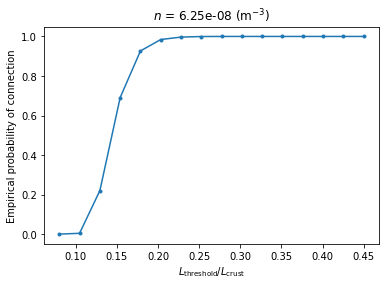

In [6]:
''' Continuum percolation data '''

def ratio_nonzero_conductivity(conductivity_vec):
  return 1.0 - (0 == ensemble_graph_conductivity[0]).astype(int).sum() / len(ensemble_graph_conductivity[0])

p_percolation = 1.0 - (0 == cond_data).astype(int).sum(axis=1) / cond_data.shape[1]
plt.plot(t_ratios, p_percolation, '.-')
plt.ylabel("Empirical probability of connection")
plt.xlabel(r"$L_\mathrm{threshold} / L_\mathrm{crust}$")

n_density = (N_chamber / x_scale / z_scale)
plt.title(f"$n$ = {n_density} " + r"(m${}^{-3}$)")


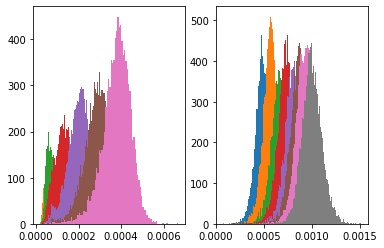

In [7]:
''' Stacked histograms '''
plt.subplot(1,2,1)
hist_n = [[0] for i in range(cond_data.shape[0])]
hist_bins = [[0] for i in range(cond_data.shape[0])]

for i in range(0, cond_data.shape[0]//2):
  nonzero_data = cond_data[i,:][np.where(cond_data[i,:] > 0)]
  if len(nonzero_data) > 0:
    hist_n[i], hist_bins[i], bars = plt.hist(nonzero_data, bins=100)

plt.subplot(1,2,2)
for i in range(cond_data.shape[0]//2, cond_data.shape[0]):
  nonzero_data = cond_data[i,:][np.where(cond_data[i,:] > 0)]
  if len(nonzero_data) > 0:
    hist_n[i], hist_bins[i], bars = plt.hist(nonzero_data, bins=100)

pmf and Gamma fits for graph effective hydraulic conductivity normalized by dissipative factors (units 1/m)


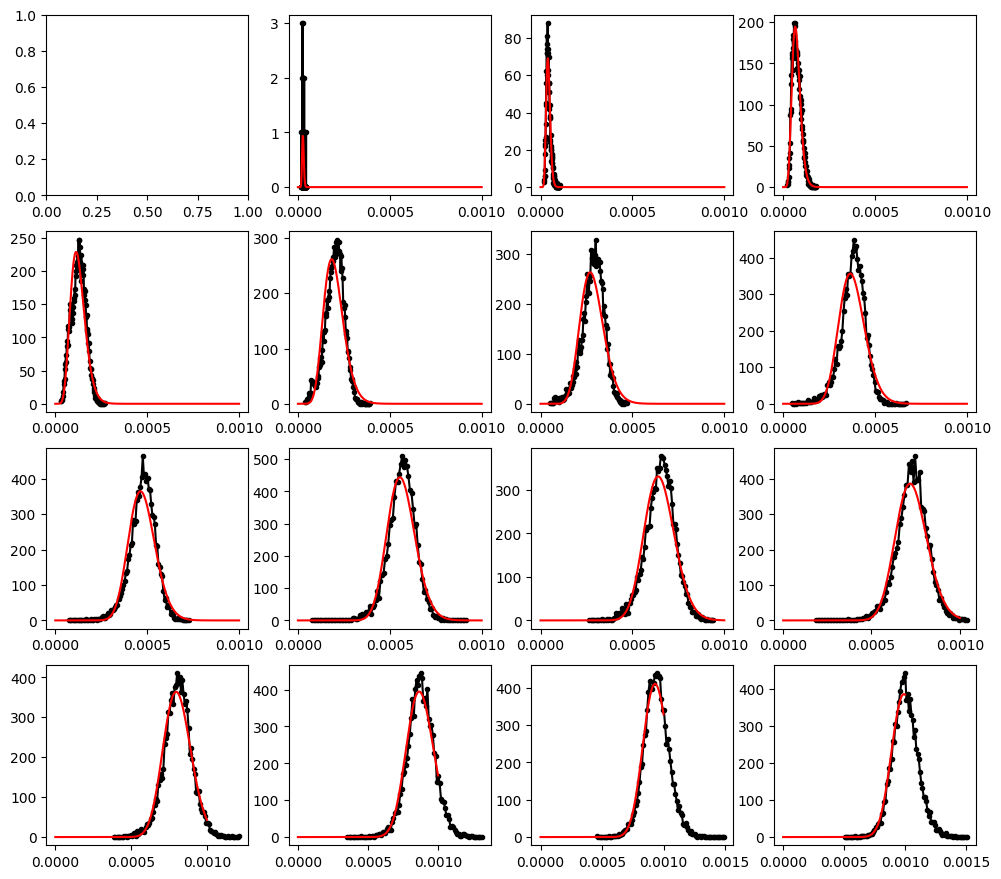

In [8]:
''' Gamma(a, scale) fits to pmf for each value of L_threshold / L_crust '''
fig =  plt.figure(figsize=(12,11), dpi=100)

param_a = np.nan * np.empty((cond_data.shape[0],))
param_loc = np.nan * np.empty((cond_data.shape[0],))
param_scale = np.nan * np.empty((cond_data.shape[0],))

for i in range(16):
  plt.subplot(4,4,i+1)
  # Extract nonzero data
  nonzero_data = cond_data[i,:][np.where(cond_data[i,:] > 0)]
  if nonzero_data.size > 0:
    # Compute histogram details
    bin_center = 0.5*(hist_bins[i][1:] + hist_bins[i][:-1])
    bin_size = (hist_bins[i][1:] - hist_bins[i][:-1])
    pmf_area = (hist_n[i] * bin_size).sum()
    # Plot histogram
    plt.plot(0.5*(hist_bins[i][1:] + hist_bins[i][:-1]), hist_n[i], 'k.-')

    # Fit continuous Gaussian
    a, loc, scale = scipy.stats.gamma.fit(cond_data[i,:][np.where(cond_data[i,:] > 0)], scale=1e-5, floc=0)
    gammafit = scipy.stats.gamma(a, loc=loc, scale=scale)
    param_a[i], param_loc[i], param_scale[i] = a, loc, scale
    # Plot Gaussian
    plot_x_scale = np.linspace(0,0.001,500)
    plt.plot(plot_x_scale, gammafit.pdf(plot_x_scale) * pmf_area, 'r')

print("pmf and Gamma fits for graph effective hydraulic conductivity normalized by dissipative factors (units 1/m)")

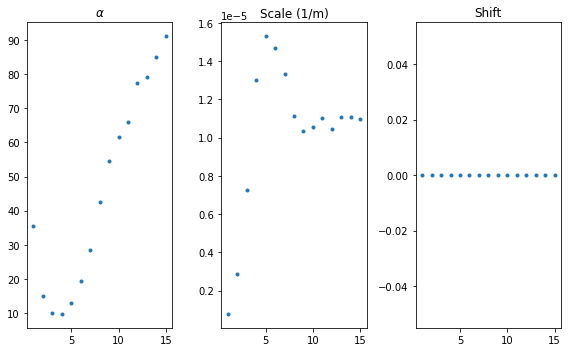

In [9]:
plt.figure(figsize=(8,5))
plt.subplot(1,3,1)
plt.plot(param_a, '.')
plt.title(rf"$\alpha$")
plt.subplot(1,3,2)
plt.plot(param_scale, '.')
plt.title("Scale (1/m)")
plt.subplot(1,3,3)
plt.plot(param_loc, '.')
plt.title("Shift")

plt.tight_layout()

Text(0, 0.5, '$Y_\\mathrm{eff}$')

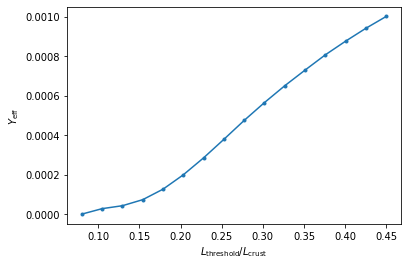

In [10]:
# Approximate (Gaussian) mean, variance
gamma_mean = np.zeros_like(param_a)
gamma_var = np.zeros_like(param_a)
for i in range(cond_data.shape[0]):
  if np.isnan(param_scale[i]):
    gamma_mean[i] = 0.0
    gamma_var[i] = 0.0
  else:
    gammafit = scipy.stats.gamma(param_a[i], loc=0, scale=param_scale[i])
    gamma_mean[i] = gammafit.mean()
    gamma_var[i] = gammafit.var()

plt.plot(t_ratios, gamma_mean, '.-')
# plt.plot(t_ratios, gamma_var, '.-')

plt.xlabel(r"$L_\mathrm{threshold} / L_\mathrm{crust}$")
plt.ylabel(r"$Y_\mathrm{eff}$")


#### Fixing $L_\mathrm{threshold} / L_\mathrm{crust}$, let's vary N to estimate the required number density for "melt propagation" in the crust

In [11]:
# Placeholder input param
ensemble_size = 500
R_chamber = 500

N_chamber_range = np.unique(np.linspace(2, 200, 16).astype(int))
Nv_ensemble_graph_conductivity = [None for i in range(len(N_chamber_range))]

for i, N_chamber in enumerate(N_chamber_range):
  Nv_ensemble_graph_conductivity[i] = percolation_network.run_2D_ensemble(
    ensemble_size, N_chamber, 10e3, 40e3,
    0.1*40e3, R_chamber, R_chamber, processes=0)


Text(0.5, 0, '$N$')

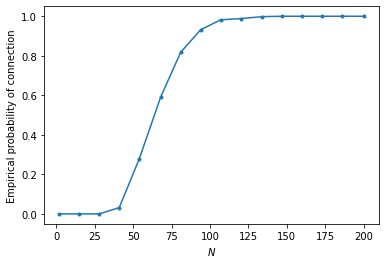

In [12]:
''' Continuum percolation data '''

Nv_cond_data = np.array(Nv_ensemble_graph_conductivity)
Nv_p_percolation = 1.0 - (0 == Nv_cond_data).astype(int).sum(axis=1) / Nv_cond_data.shape[1]
plt.plot(N_chamber_range, Nv_p_percolation, '.-')
plt.ylabel("Empirical probability of connection")
plt.xlabel(r"$N$")

# n_density = (N_chamber / x_scale / z_scale)
# plt.title(f"$n$ = {n_density} " + r"(m${}^{-3}$)")


pmf and Gamma fits for graph effective hydraulic conductivity normalized by dissipative factors (units 1/m)


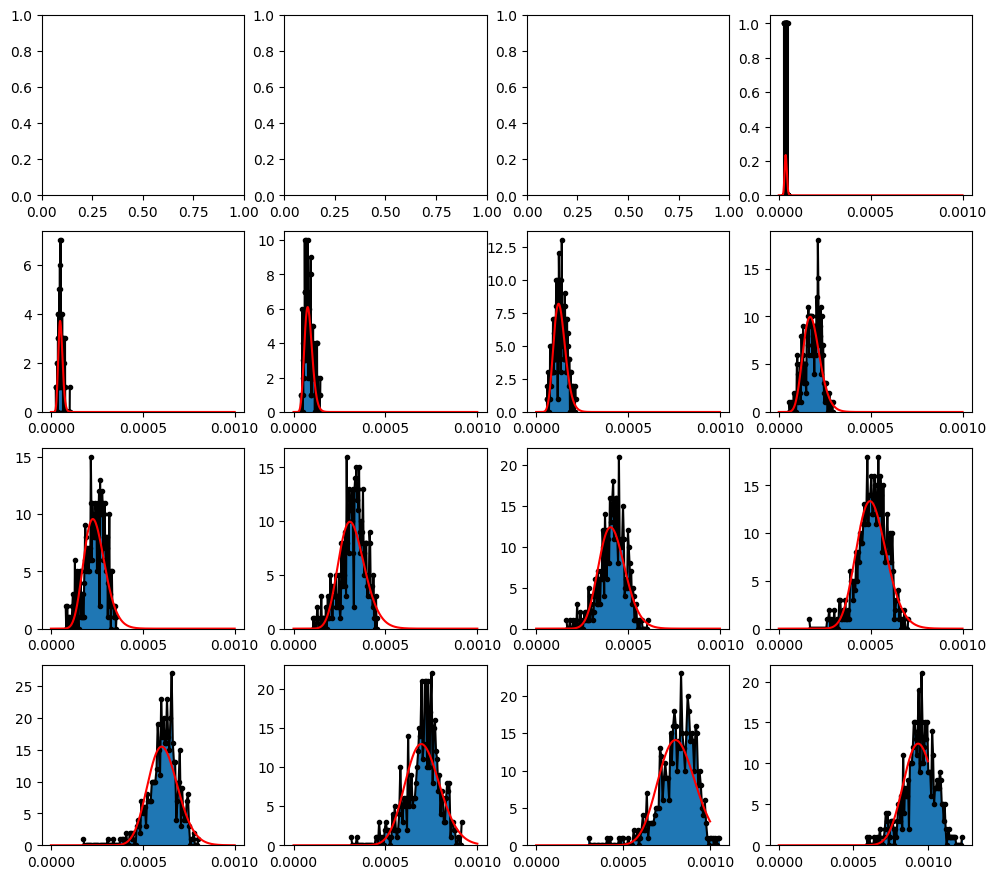

In [15]:
''' Gamma(a, scale) fits to pmf for each value of L_threshold / L_crust '''
fig =  plt.figure(figsize=(12,11), dpi=100)

Nv_param_a = np.nan * np.empty((Nv_cond_data.shape[0],))
Nv_param_loc = np.nan * np.empty((Nv_cond_data.shape[0],))
Nv_param_scale = np.nan * np.empty((Nv_cond_data.shape[0],))

for i in range(len(N_chamber_range)):
  plt.subplot(4,4,i+1)
  # Extract nonzero data
  nonzero_data = Nv_cond_data[i,:][np.where(Nv_cond_data[i,:] > 0)]
  if nonzero_data.size > 0:
    # Compute histogram details
    bins_n, bins, _ = plt.hist(nonzero_data, bins=100)
    bin_center = 0.5*(bins[1:] + bins[:-1])
    bin_size = (bins[1:] - bins[:-1])
    pmf_area = (bins_n * bin_size).sum()
    # Plot histogram
    plt.plot(0.5*(bins[1:] + bins[:-1]), bins_n, 'k.-')

    # Fit continuous Gaussian
    a, loc, scale = scipy.stats.gamma.fit(Nv_cond_data[i,:][np.where(Nv_cond_data[i,:] > 0)], scale=1e-5, floc=0)
    gammafit = scipy.stats.gamma(a, loc=loc, scale=scale)
    Nv_param_a[i], Nv_param_loc[i], Nv_param_scale[i] = a, loc, scale
    # Plot Gaussian
    plot_x_scale = np.linspace(0,0.001,500)
    plt.plot(plot_x_scale, gammafit.pdf(plot_x_scale) * pmf_area, 'r')

print("pmf and Gamma fits for graph effective hydraulic conductivity normalized by dissipative factors (units 1/m)")

Text(0, 0.5, '$Y_\\mathrm{eff}$')

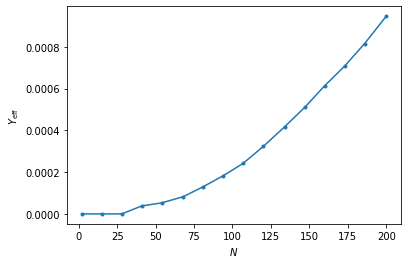

In [16]:
# Approximate (Gaussian) mean, variance
Nv_gamma_mean = np.zeros_like(Nv_param_a)
Nv_gamma_var = np.zeros_like(Nv_param_a)
for i in range(Nv_cond_data.shape[0]):
  if np.isnan(Nv_param_scale[i]):
    Nv_gamma_mean[i] = 0.0
    Nv_gamma_var[i] = 0.0
  else:
    gammafit = scipy.stats.gamma(Nv_param_a[i], loc=0, scale=Nv_param_scale[i])
    Nv_gamma_mean[i] = gammafit.mean()
    Nv_gamma_var[i] = gammafit.var()

plt.plot(N_chamber_range, Nv_gamma_mean, '.-')
# plt.plot(t_ratios, gamma_var, '.-')

plt.xlabel(r"$N$")
plt.ylabel(r"$Y_\mathrm{eff}$")


### Deterministic 2D grid

#### Varying N and threshold parameter, what are the iso-contours for hydraulic connectivity?

This provides the "null space" for model parameters, i.e., what the eruption rate can and cannot differentiate.

In [23]:
# Shuffle index
N = 5
N // 2
_x1 = np.arange(N//2-1, -1, -1)
_x2 = np.arange(N//2, N, )
_ind = np.empty((N,))
_ind[::2] = _x2
_ind[1::2] = _x1
_x1, _x2, _ind


(array([1, 0]), array([2, 3, 4]), array([2., 1., 3., 0., 4.]))

#### Residence time
In the dynamic simulation, what is the residence time of a fluid parcel transported from the bottom to the top?

This depends on flow rates (pressure-dependent) as well as a chamber residence time.